In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('placement.csv')
df.shape

(1000, 3)

In [2]:
df.sample(5)

,cgpa,placement_exam_marks,placed
97,7.33,52.0,1
859,6.52,22.0,0
487,6.95,13.0,0
572,7.66,37.0,1
792,7.92,32.0,0


C:\Users\DELL\AppData\Local\Temp\ipykernel_7276\49520821.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_7276\49520821.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


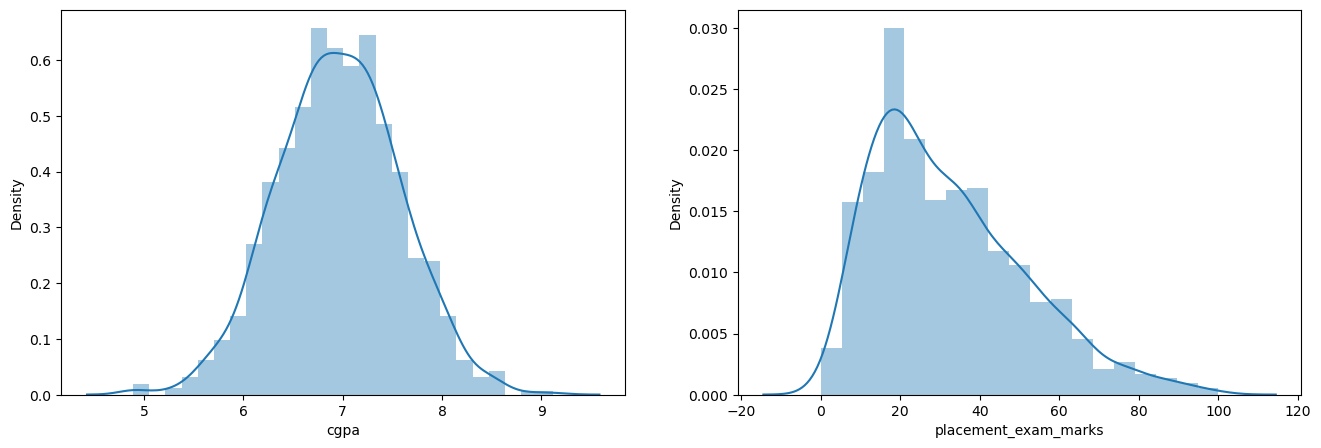

In [3]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()


In [4]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [5]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [6]:
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [7]:
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


**Trimming**

In [8]:
new_df=df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df.shape

(995, 3)

In [9]:
df['cgpa_z_score'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()
df.head()

,cgpa,placement_exam_marks,placed,cgpa_z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [11]:
df[(df['cgpa_z_score'] > 3) | (df['cgpa_z_score'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_z_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [12]:
new_df_z_score = df[(df['cgpa_z_score'] < 3) & (df['cgpa_z_score'] > -3)]
new_df_z_score.shape

(995, 4)

**Capping**

In [13]:
upper_l=df['cgpa'].mean() + 3*df['cgpa'].std()
lower_l=df['cgpa'].mean() - 3*df['cgpa'].std()
print("Upper limit",upper_l)
print("Lower limit",lower_l)

Upper limit 8.808933625397168
Lower limit 5.113546374602832


In [14]:
df['cgpa'] = np.where(df['cgpa'] > upper_l, upper_l, np.where(df['cgpa'] < lower_l, lower_l, df['cgpa']))
df.shape

(1000, 4)

In [15]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64